In [27]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, SystemMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from pypdf import PdfReader

import os
from IPython.display import display, Image

## Add Tools

In [2]:
@tool
def parse_resume(document_path):
    """This function parse the provided pdf"""

    document = PdfReader(document_path)
    document_text = document.pages[0].extract_text()

    return document_text

tools = [parse_resume]

## Load model

In [ ]:
load_dotenv()

llm_name = "llama-3.3-70b-versatile"
llm = ChatGroq(model=llm_name).bind_tools(tools)

## state_schema

In [ ]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

## Create nodes

In [5]:
def agent(state: AgentState) -> AgentState:
    
    system_prompt = SystemMessage(
        content="You are a proffessional HR, who can read the documents, cv's and recommend the best job that fits for the client"
    )

    response = llm.invoke([system_prompt] + state["messages"])

    return {"messages": [response]}

def tool_selection(state: AgentState):

    last_message = state["messages"][-1]

    if last_message.tool_calls:

        return "continue"
    else:

        return "end"

## Create graph

In [6]:
graph = StateGraph(AgentState)

tool_node = ToolNode(tools=tools)

graph.add_node("agent", agent)
graph.add_node("tool_node", tool_node)


graph.add_edge(START, "agent")

graph.add_conditional_edges(
    "agent",
    tool_selection,

    {
        "continue": "tool_node",
        "end": END
    }
)

graph.add_edge("tool_node", "agent")


app = graph.compile()

## Draw graph

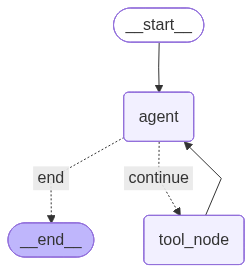

In [7]:
display(Image(app.get_graph().draw_mermaid_png()))

## Invoke llm

In [24]:
response = app.stream(AgentState(messages=["hi"]), stream_mode="values")

In [26]:
stream_list = list(response)

content='hi' additional_kwargs={} response_metadata={} id='0dc1fb43-d9dd-4176-94a0-4165fb37f5d0'
content='Hello. How can I assist you today? Are you looking for help with finding a job or would you like me to review a resume or any other document?' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 239, 'total_tokens': 272, 'completion_time': 0.161311293, 'completion_tokens_details': None, 'prompt_time': 0.03680876, 'prompt_tokens_details': None, 'queue_time': 0.017733166, 'total_time': 0.198120053}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e1566-befb-7fb3-8a0f-13f339ae9531-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 239, 'output_tokens': 33, 'total_tokens': 272}


In [22]:
def print_stream(stream):

    try:

        for s in stream:

            message = s['messages'][-1]

            if isinstance(message, tuple):

                print(message)
            else:

                message.pretty_print()

    except Exception as e:

        print(f"{e}")

        with open("Errors/error_log.txt", 'a') as file:

            file.write(f"\n{str(e)}")


user_input = input("\nEnter prompt: ")

while user_input != "exit":

    stream = app.stream(AgentState(messages=[user_input]), stream_mode="values")

    print("\n")

    print_stream(stream)

    user_input = input("\n\nEnter prompt: ")



================================ Human Message =================================

resume
================================== Ai Message ==================================
Tool Calls:
  parse_resume (wnrckrsd7)
 Call ID: wnrckrsd7
  Args:
    document_path: resume.pdf
[Errno 2] No such file or directory: 'resume.pdf'


================================ Human Message =================================

again
================================== Ai Message ==================================
Tool Calls:
  parse_resume (9shhz35fx)
 Call ID: 9shhz35fx
  Args:
    document_path: client_resume.pdf
[Errno 2] No such file or directory: 'client_resume.pdf'


In [ ]:
conversation_history = []

if os.path.exists("conversation_history.txt"):

    with open("conversation_history.txt", 'r') as file:

        lines = file.readlines()
        
        for line in lines:

            if line.__contains__("human"):

                index = line.find(':') + 1
                conversation_history.append(HumanMessage(content=line[index:]))

            elif line.__contains__("AI"):

                index = line.find(':') + 1
                conversation_history.append(AIMessage(content=line[index:]))
    

user_input = input("Enter prompt: ")

while(user_input != "exit"):

    conversation_history.append(HumanMessage(content=user_input))

    response = app.invoke(AgentState(messages=conversation_history))

    conversation_history = response['messages']

    user_input = input("Enter prompt: ")

    if user_input == "exit":

        with open("conversation_history.txt", 'w') as file:

            for message in conversation_history:

                if isinstance(message, HumanMessage):

                    file.write(f"\nhuman: {message.content}")
                elif isinstance(message, AIMessage):

                    file.write(f"\nAI: {message.content}")